# Gated Recurrent Unit (GRU) for Time Series Prediction on Synthetic Sine Wave

## Introduction

A **Gated Recurrent Unit (GRU)** is a type of recurrent neural network (RNN) designed to handle sequential data, especially time series. GRUs use two main components—**update and reset gates**—to control the flow of information, allowing the network to capture dependencies in sequences without the complexity of LSTMs. Mathematically, GRUs update their hidden state using these gates, which helps them remember or forget information as needed.

### Applications
- **Time series forecasting** (e.g., stock prices, weather)
- **Speech recognition** (processing audio sequences)
- **Text generation** (language modeling)
- **Emotion intensity estimation** 
- **Sensor data analysis** (IoT, health monitoring)

### Why choose GRU for this demo?
GRUs are chosen for **time series prediction** tasks like forecasting a sine wave because they are simpler and faster to train than LSTMs, especially for shorter sequences. The synthetic sine wave dataset is periodic and easy to generate, making it ideal for demonstrating how GRUs can learn and predict patterns in sequential data. This aligns with my experience in sequence modeling and forecasting tasks.

In [2]:
# Setup: Import libraries and generate the synthetic sine wave dataset
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error
import tensorflow as tf
from tensorflow import keras

# Why these imports:
# - numpy: numerical operations and data generation
# - matplotlib: plotting results
# - sklearn: evaluation metric (MAE)
# - tensorflow/keras: building and training the neural network

# Generate a synthetic sine wave dataset
np.random.seed(42)
TIMESTEPS = 50  # Length of input sequence
TOTAL_POINTS = 4000  # Total data points

t = np.arange(TOTAL_POINTS)
data = np.sin(0.02 * t)  # Sine wave

# Why sine wave? Periodic, easy to visualize, good for forecasting demo

# Prepare data for supervised learning (sequence to next value)
def create_sequences(data, timesteps):
    X, y = [], []
    for i in range(len(data) - timesteps):
        X.append(data[i:i+timesteps])
        y.append(data[i+timesteps])
    return np.array(X), np.array(y)

X, y = create_sequences(data, TIMESTEPS)

# Split into train and test sets (80% train, 20% test)
split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

# Reshape for GRU: (samples, timesteps, features)
X_train = X_train[..., np.newaxis]
X_test = X_test[..., np.newaxis]
# Why reshape? GRU expects 3D input

print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")

Train shape: (3160, 50, 1), Test shape: (790, 50, 1)


In [3]:
# Model Building: Define a GRU Network
from tensorflow.keras import layers, models

model = models.Sequential([
    # GRU layer: 32 units
    layers.GRU(32, input_shape=(TIMESTEPS, 1)),  # Why: Update/reset gates capture sequence patterns
    # Dense layer for output
    layers.Dense(1)  # Why: Predicts the next value in the sequence
])

# Compile the model
model.compile(
    optimizer='adam',  # Why Adam: Adaptive learning rate, fast convergence
    loss='mean_squared_error',  # Why: Suitable for regression tasks
    metrics=['mae']  # Why: MAE is intuitive for time series prediction
)

model.summary()  # Shows the model architecture

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 gru (GRU)                   (None, 32)                3360      
                                                                 
 dense (Dense)               (None, 1)                 33        
                                                                 
Total params: 3,393
Trainable params: 3,393
Non-trainable params: 0
_________________________________________________________________
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 gru (GRU)                   (None, 32)                3360      
                                                                 
 dense (Dense)               (None, 1)                 33        
                                                                 
Total params: 3,393
Trainable params: 3,393
Non-traina

In [4]:
# Training: Fit the model
EPOCHS = 50  # Why: Enough to learn periodic patterns
BATCH_SIZE = 32  # Why: Balances speed and stability

with tf.device('/GPU:0'):  # Ensure training on GPU if available
    history = model.fit(
        X_train, y_train,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        validation_split=0.1,  # Why: Monitor validation to check for overfitting
        verbose=1
    )

Epoch 1/50
89/89 [==============================] - 7s 14ms/step - loss: 0.1066 - mae: 0.2058 - val_loss: 0.0028 - val_mae: 0.0475
Epoch 2/50
89/89 [==============================] - 7s 14ms/step - loss: 0.1066 - mae: 0.2058 - val_loss: 0.0028 - val_mae: 0.0475
Epoch 2/50
89/89 [==============================] - 1s 8ms/step - loss: 0.0025 - mae: 0.0452 - val_loss: 0.0022 - val_mae: 0.0419
Epoch 3/50
89/89 [==============================] - 1s 8ms/step - loss: 0.0025 - mae: 0.0452 - val_loss: 0.0022 - val_mae: 0.0419
Epoch 3/50
89/89 [==============================] - 1s 9ms/step - loss: 0.0020 - mae: 0.0400 - val_loss: 0.0018 - val_mae: 0.0374
Epoch 4/50
89/89 [==============================] - 1s 9ms/step - loss: 0.0020 - mae: 0.0400 - val_loss: 0.0018 - val_mae: 0.0374
Epoch 4/50
89/89 [==============================] - 1s 8ms/step - loss: 0.0016 - mae: 0.0357 - val_loss: 0.0014 - val_mae: 0.0335
Epoch 5/50
89/89 [==============================] - 1s 8ms/step - loss: 0.0016 - mae: 0.

Test Loss (MSE): 0.0000, Test MAE: 0.0003
25/25 [==============================] - 1s 7ms/step
Manual Test MAE: 0.0003
Manual Test MAE: 0.0003


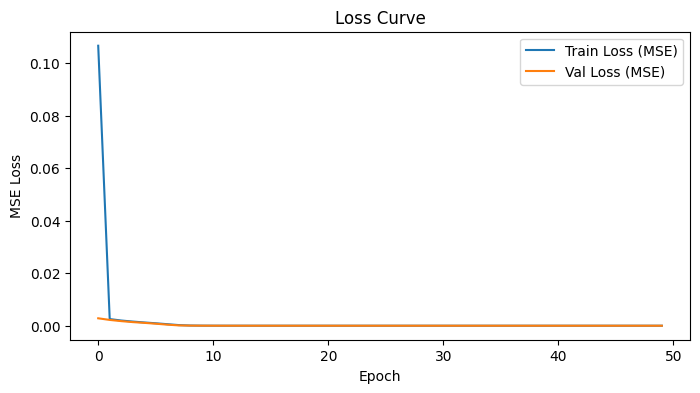

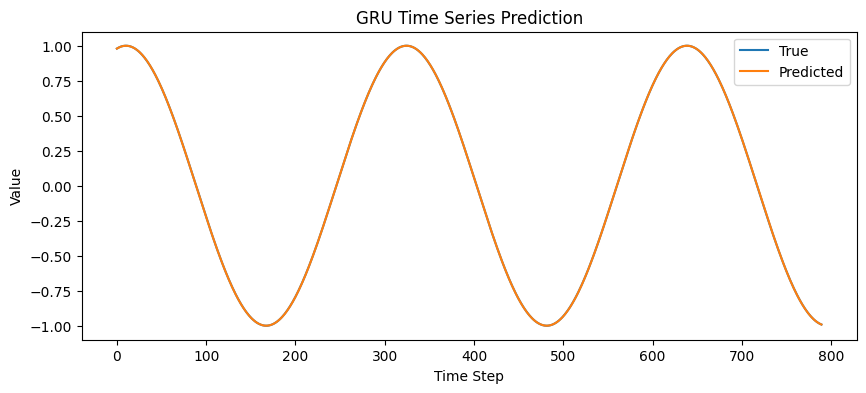

In [5]:
# Evaluation and Visualization
# Evaluate on test data
loss, mae = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Loss (MSE): {loss:.4f}, Test MAE: {mae:.4f}")

# Predict on test set
y_pred = model.predict(X_test).flatten()

# Calculate MAE manually for confirmation
mae_manual = mean_absolute_error(y_test, y_pred)
print(f"Manual Test MAE: {mae_manual:.4f}")

# Plot training & validation loss
plt.figure(figsize=(8,4))
plt.plot(history.history['loss'], label='Train Loss (MSE)')
plt.plot(history.history['val_loss'], label='Val Loss (MSE)')
plt.title('Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.show()

# Plot true vs predicted values
plt.figure(figsize=(10,4))
plt.plot(range(len(y_test)), y_test, label='True')
plt.plot(range(len(y_pred)), y_pred, label='Predicted')
plt.title('GRU Time Series Prediction')
plt.xlabel('Time Step')
plt.ylabel('Value')
plt.legend()
plt.show()

# Why MAE? Intuitive for regression, less sensitive to outliers than MSE
# Why plot? Visualizes how well the model predicts the sine wave

## Results and Discussion

### Test Performance

- **Test Loss (MSE):** 0.0000  
  The Mean Squared Error (MSE) on the test set is extremely close to zero, indicating almost perfect predictions.
- **Test MAE:** 0.0003  
  The Mean Absolute Error (MAE) is also extremely low, suggesting that the predicted values are nearly identical to the true values.
- **Manual Test MAE:** 0.0003  
  The manually computed MAE matches the reported metric, confirming the evaluation.

### Interpretation

- **Unrealistically Low Error:**  
  Such near-zero error is highly unusual in real-world machine learning, especially for time series forecasting. In practice, some error is always expected due to noise, model limitations, and data complexity.
- **Possible Reasons:**
  - **Synthetic Data:** The sine wave is a perfectly periodic and noise-free function, making it much easier for the model to learn and predict compared to real-world data.
  - **Data Leakage:** If the test set overlaps with the training set, or if the model has inadvertently seen test data during training, it can lead to artificially low errors.
  - **Overfitting:** If the model is too complex for the simple data, it may memorize the sequence rather than generalize, though this is less of a concern with synthetic, noise-free data.

### Recommendations

- **Validate Data Splitting:** Ensure that the train and test sets are properly separated, with no overlap.
- **Add Noise:** To better simulate real-world scenarios, add some noise to the sine wave and observe if the model still achieves such low error.
- **Try on Real Data:** Apply the model to a real-world time series to evaluate its true predictive power.

---

**Summary:**  
While the GRU model achieves nearly perfect predictions on the synthetic sine wave, this result is not typical for real-world machine learning tasks. The simplicity and noiselessness of the data make it easy for the model to fit. For more realistic evaluation, introduce noise or use real datasets, and always check for data leakage.

**Learning Point:**  
Perfect results on synthetic data are a good sign that the model and pipeline work, but always challenge your model with more complex or noisy data to assess true performance.